# 04 - Model Evaluation

- Load the saved models
- Load the test dataset
- Evaluate each model on the test set
- Compare the final results
- Create confusion matrices
- Plot ROC curves
- Review feature importance
- Select the best model

#### Import libraries

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

#### Load the test dataset

In [2]:
test_data = pd.read_csv(
    "../DataSet/processed/telco_churn_test.csv"
)

print("Test data shape:", test_data.shape)

Test data shape: (1055, 47)


#### Preview the test data

In [3]:
test_data.head()

,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,...,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen_0,SeniorCitizen_1,Churn
0,-0.792793,0.324107,-0.582040,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0
1,0.549528,0.803370,0.857740,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0
2,1.200350,0.702560,1.283487,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0
3,-1.158880,0.370381,-0.866260,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1
4,-1.118204,0.960370,-0.792521,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1


#### Separate the features and target

In [4]:
X_test = test_data.drop(columns=["Churn"])
y_test = test_data["Churn"]

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (1055, 46)
y_test: (1055,)


#### Load the trained models

In [5]:
logistic_model = joblib.load(
    "../models/logistic_regression.joblib"
)

decision_tree_model = joblib.load(
    "../models/decision_tree.joblib"
)

random_forest_model = joblib.load(
    "../models/random_forest.joblib"
)

mlp_model = joblib.load(
    "../models/mlp.joblib"
)

print("All trained models loaded.")

All trained models loaded.


#### Create an evaluation function

In [6]:
def evaluate_model(model_name, model, X, y):
    predictions = model.predict(X)
    probabilities = model.predict_proba(X)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y, predictions),
        "Precision": precision_score(y, predictions),
        "Recall": recall_score(y, predictions),
        "F1-Score": f1_score(y, predictions),
        "ROC-AUC": roc_auc_score(y, probabilities)
    }

    return results

#### Evaluate all models

In [7]:
logistic_results = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_test,
    y_test
)

decision_tree_results = evaluate_model(
    "Decision Tree",
    decision_tree_model,
    X_test,
    y_test
)

random_forest_results = evaluate_model(
    "Random Forest",
    random_forest_model,
    X_test,
    y_test
)

mlp_results = evaluate_model(
    "Multi-Layer Perceptron",
    mlp_model,
    X_test,
    y_test
)

#### Compare the test results

In [8]:
test_results = pd.DataFrame([
    logistic_results,
    decision_tree_results,
    random_forest_results,
    mlp_results
])

test_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.787678,0.616667,0.528571,0.569231,0.822177
1,Decision Tree,0.776303,0.600000,0.471429,0.528000,0.810970
2,Random Forest,0.779147,0.608295,0.471429,0.531187,0.819217
3,Multi-Layer Perceptron,0.778199,0.590551,0.535714,0.561798,0.809412


#### Sort the models by ROC-AUC

In [9]:
sorted_results = test_results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

sorted_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.787678,0.616667,0.528571,0.569231,0.822177
1,Random Forest,0.779147,0.608295,0.471429,0.531187,0.819217
2,Decision Tree,0.776303,0.600000,0.471429,0.528000,0.810970
3,Multi-Layer Perceptron,0.778199,0.590551,0.535714,0.561798,0.809412


#### Save the test results

In [10]:
test_results.to_csv(
    "../models/test_results.csv",
    index=False
)

print("Test results were saved.")

Test results were saved.


#### Display classification reports

In [11]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "Multi-Layer Perceptron": mlp_model
}

for model_name, model in models.items():
    predictions = model.predict(X_test)

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(classification_report(y_test, predictions))

Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       775
           1       0.62      0.53      0.57       280

    accuracy                           0.79      1055
   macro avg       0.73      0.70      0.71      1055
weighted avg       0.78      0.79      0.78      1055

Decision Tree
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       775
           1       0.60      0.47      0.53       280

    accuracy                           0.78      1055
   macro avg       0.71      0.68      0.69      1055
weighted avg       0.76      0.78      0.77      1055

Random Forest
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       775
           1       0.61      0.47      0.53       280

    accuracy                           0.78      1055
   macro avg       0.72      0.68      0.69      1055
weighted avg       0.77   

#### Create confusion matrices

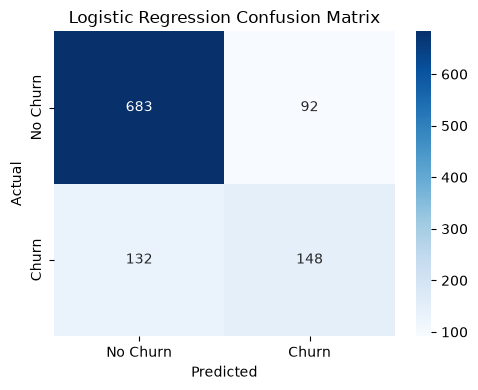

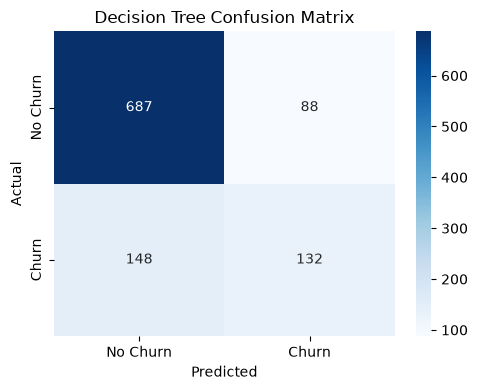

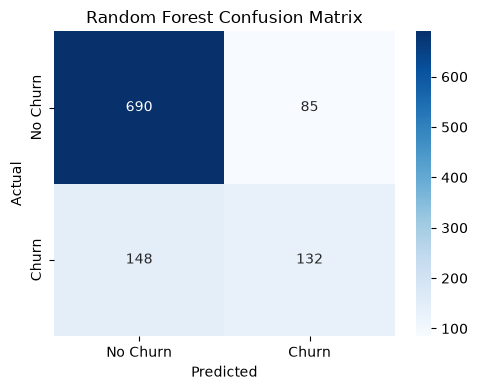

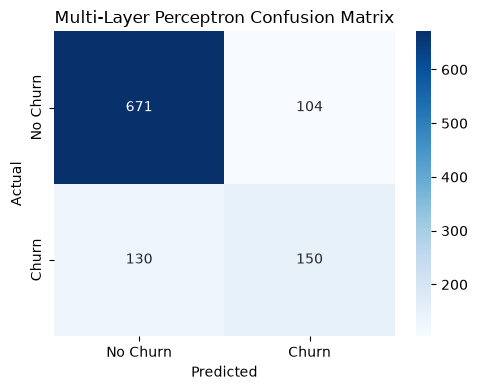

In [12]:
for model_name, model in models.items():
    predictions = model.predict(X_test)
    matrix = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

#### Plot ROC curves

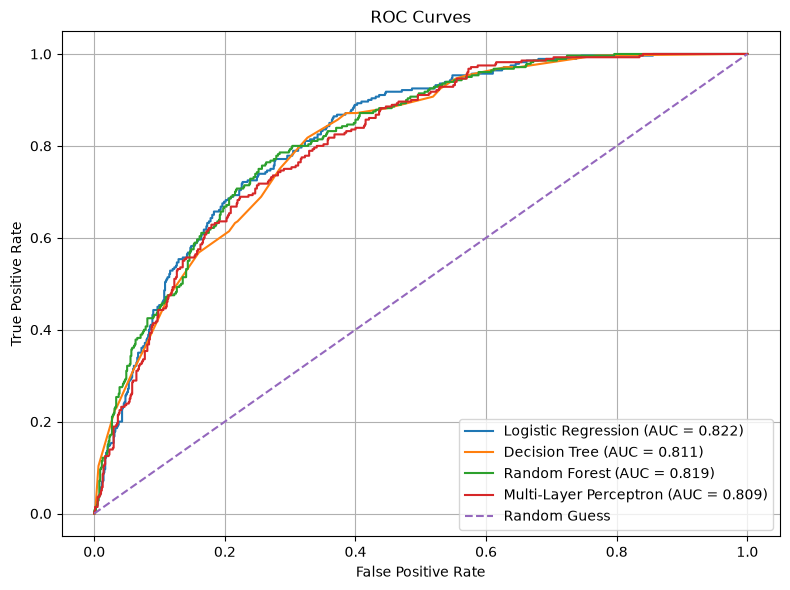

In [13]:
plt.figure(figsize=(8, 6))

for model_name, model in models.items():
    probabilities = model.predict_proba(X_test)[:, 1]

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

#### Compare model performance

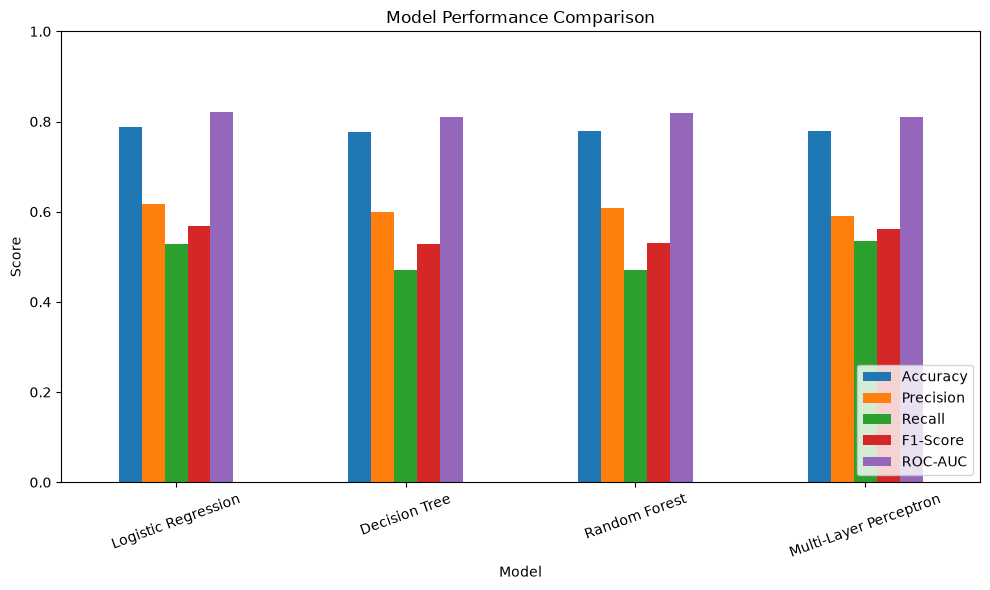

In [14]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

test_results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#### Random Forest feature importance

In [15]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,tenure,0.143732
2,TotalCharges,0.128301
1,MonthlyCharges,0.094015
35,Contract_Month-to-month,0.087638
17,OnlineSecurity_No,0.044908
26,TechSupport_No,0.038328
42,PaymentMethod_Electronic check,0.037788
15,InternetService_Fiber optic,0.037694
37,Contract_Two year,0.031462
20,OnlineBackup_No,0.021231


#### Plot the most important features

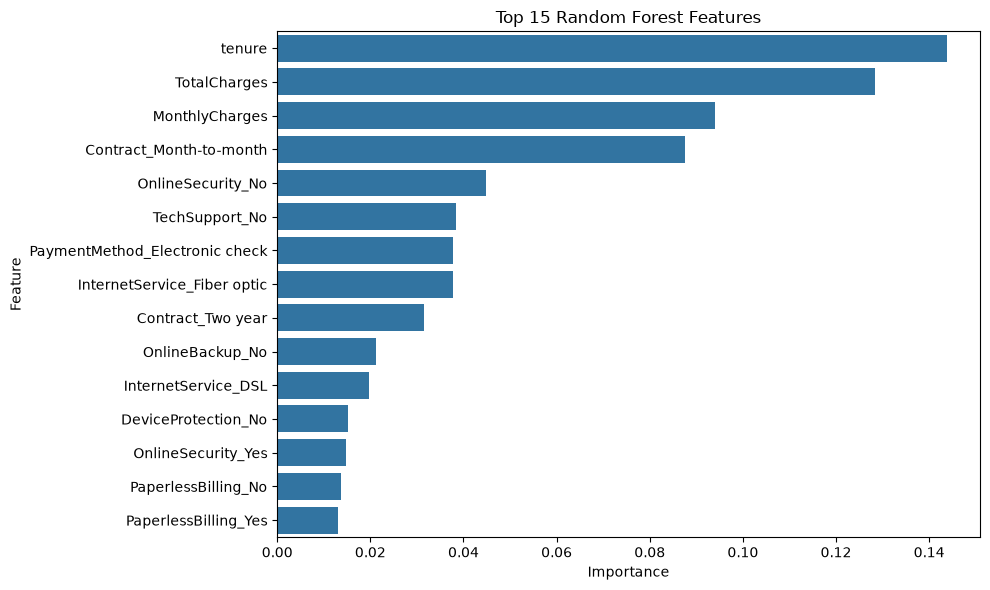

In [16]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### Find the best model

In [17]:
best_model = sorted_results.iloc[0]

print("Best model:", best_model["Model"])
print("Accuracy:", round(best_model["Accuracy"], 4))
print("Precision:", round(best_model["Precision"], 4))
print("Recall:", round(best_model["Recall"], 4))
print("F1-Score:", round(best_model["F1-Score"], 4))
print("ROC-AUC:", round(best_model["ROC-AUC"], 4))

Best model: Logistic Regression
Accuracy: 0.7877
Precision: 0.6167
Recall: 0.5286
F1-Score: 0.5692
ROC-AUC: 0.8222


#### Final Model Selection

The best-performing model was **Logistic Regression**. It achieved the highest ROC-AUC score and also performed well in accuracy, recall, and F1-score.

This model was selected because it gave the best overall performance on the test dataset. Recall is especially important for this project because it shows how well the model identifies customers who are likely to leave.

## Summary

Four trained models were evaluated using the test dataset:

- Logistic Regression
- Decision Tree
- Random Forest
- Multi-Layer Perceptron

The models were compared using accuracy, precision, recall, F1-score, and ROC-AUC. Confusion matrices and ROC curves were also created. Random Forest feature importance was reviewed to identify the features that had the largest effect on customer churn predictions.